# Task 1 — CDL Crop Mapping & Weekly NDVI Phenology

**Pipeline overview:**
1. Install dependencies (`requirements.txt`)
2. Define state bboxes (EPSG:5070), CDL colour palette, and helper functions
3. For each state/year in `config.json`:
   - Download CDL GeoTIFF → extract corn & soybean pixel masks
   - Download growing-season weekly NDVI → reproject to CDL grid
   - Extract per-crop NDVI statistics → save CSV + phenology plot

**Config file:** `config.json` — keys `states` (list of state names) and `years` (list of ints)


In [19]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [20]:
# Standard library
import os
import glob
import time
import json
import random
import datetime
from datetime import datetime, date
from collections import Counter
from io import BytesIO

# Third-party packages
import numpy as np
import pandas as pd
import requests

import rasterio
from rasterio.warp import reproject, Resampling
from datetime import date, timedelta
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

from PIL import Image

print("All imports OK")


All imports OK


In [21]:
# ✓ Iowa was the only one correct — all others recomputed from WGS84 → EPSG:5070
STATE_BBOXES = {
    "17": { "state": "ILLINOIS",      "bbox": "396000,1557000,732000,2203000"    },
    "18": { "state": "INDIANA",       "bbox": "689000,1666000,924000,2139000"    },
    "19": { "state": "IOWA",          "bbox": "-54000,1929000,471000,2293000"    },  # was already correct
    "20": { "state": "KANSAS",        "bbox": "-533000,1567000,119000,1888000"   },
    "26": { "state": "MICHIGAN",      "bbox": "461000,2091000,1014000,2885000"   },
    "27": { "state": "MINNESOTA",     "bbox": "-100000,2279000,479000,2946000"   },
    "29": { "state": "MISSOURI",      "bbox": "21000,1438000,578000,1976000"     },
    "31": { "state": "NEBRASKA",      "bbox": "-680000,1916000,56000,2223000"    },
    "38": { "state": "NORTH DAKOTA",  "bbox": "-624000,2576000,-41000,2888000"   },
    "39": { "state": "OHIO",          "bbox": "965000,1764000,1268000,2212000"   },
    "46": { "state": "SOUTH DAKOTA",  "bbox": "-658000,2192000,-34000,2550000"   },
    "55": { "state": "WISCONSIN",     "bbox": "254000,2170000,743000,2715000"    },
}


# Official USDA CDL colour palette (subset)
CDL_LEGEND = {0:   ("Background",           "#000000"),1:   ("Corn",                 "#FFD300"),2:   ("Cotton",               "#FF2626"),3:   ("Rice",                 "#00A8E2"),4:   ("Sorghum",              "#FF9E0A"),5:   ("Soybeans",             "#267000"),6:   ("Sunflower",            "#FFD9D9"),21:  ("Barley",               "#A57000"),22:  ("Durum Wheat",          "#D3D300"),23:  ("Spring Wheat",         "#A5A500"),24:  ("Winter Wheat",         "#D3FF70"),26:  ("Dbl WinWht/Soy",       "#A5FF8C"),27:  ("Rye",                  "#70A500"),28:  ("Oats",                 "#70D000"),29:  ("Millet",               "#A57000"),36:  ("Alfalfa",              "#00AF4C"),37:  ("Other Hay",            "#00D000"),41:  ("Sugarbeets",           "#A800E2"),42:  ("Dry Beans",            "#A50000"),61:  ("Fallow/Idle",          "#B8AF93"),63:  ("Forest",               "#93CC93"),82:  ("Developed",            "#9C9C9C"),83:  ("Water",                "#4C70AF"),87:  ("Wetlands",             "#7FB3C8"),111: ("Open Water",           "#4C70AF"),121: ("Dev/Open Space",       "#9C9C9C"),122: ("Dev/Low",              "#9C9C9C"),123: ("Dev/Med",              "#9C9C9C"),124: ("Dev/High",             "#9C9C9C"),141: ("Deciduous Forest",     "#93CC93"),142: ("Evergreen Forest",     "#93CC93"),143: ("Mixed Forest",         "#93CC93"),152: ("Shrubland",            "#C6D69C"),176: ("Grassland/Pasture",    "#E8FFBE"),190: ("Woody Wetlands",       "#7FB3C8"),195: ("Herbaceous Wetlands",  "#7FB3C8"),
}
print(f"Palette loaded — {len(CDL_LEGEND)} entries")

Palette loaded — 36 entries


In [22]:
def download_cdl_tif(year, fips, out_path, retries=4, delay=20):
    """
    Download a state-level CDL GeoTIFF via the CropScape REST API.

    Parameters
    ----------
    year     : int   — CDL year (2008–2025)
    fips     : str   — 2-digit state FIPS code ('19' = Iowa)
    out_path : str   — where to save the .tif
    """
    if os.path.exists(out_path):
        print(f"[CDL {year}] Already exists: {out_path}")
        return True
    CROPSCAPE_BASE = "https://nassgeodata.gmu.edu/axis2/services/CDLService"
    # Step 1: request the file — API returns a URL to the actual TIF
    request_url = (
        f"{CROPSCAPE_BASE}/GetCDLFile"
        f"?year={year}&fips={fips}"
    )
    print(f"[CDL {year}] Requesting {state_name} TIF from CropScape API...")
    print(f"  {request_url}")

    for attempt in range(1, retries + 1):
        try:
            r = requests.get(request_url, timeout=60)
            r.raise_for_status()

            # Response is XML containing the download URL
            # e.g. <returnURL>https://...cdl_2025_19.tif</returnURL>
            import re
            match = re.search(r'<returnURL>(.*?)</returnURL>', r.text)
            if not match:
                print(f"  Attempt {attempt}: Unexpected response:\n  {r.text[:200]}")
                time.sleep(delay)
                continue

            tif_url = match.group(1).strip()
            print(f"  Got TIF URL: {tif_url}")

            # Step 2: download the actual TIF
            print(f"  Downloading TIF (this may take a while for 10 m res)...")
            tif_resp = requests.get(tif_url, timeout=300, stream=True)
            tif_resp.raise_for_status()

            with open(out_path, "wb") as f:
                for chunk in tif_resp.iter_content(chunk_size=1024 * 1024):
                    f.write(chunk)

            size_mb = os.path.getsize(out_path) / (1024 ** 2)
            print(f"  ✓ Saved {size_mb:.1f} MB → {out_path}")
            return True

        except Exception as e:
            print(f"  Attempt {attempt} error: {e}")
            time.sleep(delay * attempt)

    print(f"[CDL {year}] ✗ All {retries} attempts failed.")
    return False


In [23]:
def week_start_end_from_iso(year, week):
    """
    Return Monday and Sunday date strings for an ISO week.
    Output format: YYYY.MM.DD
    """
    start_dt = date.fromisocalendar(year, week, 1)   # Monday
    end_dt = date.fromisocalendar(year, week, 7)     # Sunday
    return start_dt.strftime("%Y.%m.%d"), end_dt.strftime("%Y.%m.%d")


def build_weekly_layer_name(year, week):
    """
    Crop-CASMA weekly NDVI layer format:
    NDVI-WEEKLY_YYYY_WW_YYYY.MM.DD_YYYY.MM.DD
    """
    start_str, end_str = week_start_end_from_iso(year, week)
    return f"NDVI-WEEKLY_{year}_{week:02d}_{start_str}_{end_str}"


def download_ndvi_weekly_tiff(
    year,
    week,
    out_path,
    bbox="-52095.0,1938165.0,481755.0,2288295.0",
    width=2000,
    height=1500,
):
    layer = build_weekly_layer_name(year, week)

    url = (
        "https://nassgeo.csiss.gmu.edu/cgi-bin/mapserv"
        "?SERVICE=WMS&VERSION=1.3.0&REQUEST=GetMap"
        f"&MAP=/DATA/SMAP_DATA/WMS/NDVI-WEEKLY_{year}.map"
        f"&LAYERS={layer}"
        "&CRS=EPSG:5070"
        "&FORMAT=image/tiff"
        f"&BBOX={bbox}"
        f"&WIDTH={width}&HEIGHT={height}"
    )

    r = requests.get(url, timeout=120)
    ct = r.headers.get("Content-Type", "")
    print(f"  {layer}  →  HTTP {r.status_code}  ({ct})")

    if "tiff" in ct.lower():
        with open(out_path, "wb") as f:
            f.write(r.content)
        return True
    else:
        print("  ERROR — response:", r.text[:500])
        return False
# def reproject_to_match(src_array, src_profile, dst_profile):
#     """Reproject src_array onto dst_profile's grid using bilinear resampling."""
#     dst = np.empty((dst_profile["height"], dst_profile["width"]), dtype=np.float32)
#     reproject(
#         source=src_array.astype(np.float32),
#         destination=dst,
#         src_transform=src_profile["transform"],
#         src_crs=src_profile["crs"],
#         dst_transform=dst_profile["transform"],
#         dst_crs=dst_profile["crs"],
#         resampling=Resampling.bilinear,
#     )
#     return dst

def reproject_to_match(src_array, src_profile, dst_profile):
    dst = np.full(
        (dst_profile["height"], dst_profile["width"]),
        fill_value=np.nan,
        dtype=np.float32
    )
    reproject(
        source=src_array,
        destination=dst,
        src_transform=src_profile["transform"],
        src_crs=src_profile["crs"],
        dst_transform=dst_profile["transform"],
        dst_crs=dst_profile["crs"],
        resampling=Resampling.bilinear,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    return dst

def get_growing_season_weeks(year, start_month=3, start_day=1, end_month=10, end_day=10):
    """
    Generate ISO year/week pairs covering the growing season.

    Default season:
        March 1 -> October 10

    Returns
    -------
    list[tuple[int, int]]
        [(iso_year, iso_week), ...]
    """
    start_dt = date(year, start_month, start_day)
    end_dt = date(year, end_month, end_day)

    seen = set()
    weeks = []

    current = start_dt
    while current <= end_dt:
        iso_year, iso_week, _ = current.isocalendar()
        if (iso_year, iso_week) not in seen:
            seen.add((iso_year, iso_week))
            weeks.append((iso_year, iso_week))
        current += timedelta(days=7)

    print("Growing season weeks:")
    for iso_year, iso_week in weeks:
        print(f"  {iso_year} week {iso_week:02d}")

    return weeks


def download_growing_season_weekly_ndvi(
    year,
    out_dir,
    bbox="-52095.0,1938165.0,481755.0,2288295.0",
    width=2000,
    height=1500,
    mapfile_year=2025,
    layer_prefix="NDVI-WEEKLY",
):
    """
    Download all weekly NDVI layers for the growing season.
    """
    os.makedirs(out_dir, exist_ok=True)

    weeks = get_growing_season_weeks(year)
    downloaded = []

    for iso_year, iso_week in weeks:
        out_name = f"{layer_prefix}_{iso_year}_{iso_week:02d}.tif"
        out_path = os.path.join(out_dir, out_name)

        ok = download_ndvi_weekly_tiff(
            year=iso_year,
            week=iso_week,
            out_path=out_path,
            bbox=bbox,
            width=width,
            height=height,
            mapfile_year=mapfile_year,
            layer_prefix=layer_prefix,
        )

        if ok:
            downloaded.append(out_path)

    print(f"\nDownloaded {len(downloaded)} weekly files.")
    return downloaded


print("Weekly NDVI helper functions defined.")

Weekly NDVI helper functions defined.


In [24]:
def get_state_info(state_name, state_bboxes=STATE_BBOXES, state_fips=None):
    """
    Retrieve FIPS code and bounding box for a specified state name.
    """
    # Create the reverse lookup mapping
    name_to_info = {
        v["state"].upper(): (k, v["bbox"])
        for k, v in state_bboxes.items()
    }

    key = state_name.upper().strip()

    if key in name_to_info:
        fips, bbox = name_to_info[key]
        print(f"FIPS of {state_name} is {fips}")
        print(f"BBOX of {state_name} is {bbox}")
        return fips, bbox
    else:
        # Fallback for states not in STATE_BBOXES
        fips = state_fips.get(key) if state_fips else None
        print(f"FIPS of {state_name} is {fips}")
        print(f"Warning: {state_name} has no bbox in STATE_BBOXES")
        return fips, None

# Example usage:
# fips, bbox = get_state_info(state_name)


In [25]:

def plot_top_cdl_classes(cdl, state_name, year, top_n=10, cdl_legend_lookup=CDL_LEGEND, save_dir="cdl_plots"):
    """
    Counts pixels per CDL class, maps the top-N classes using the official palette,
    and plots the overview alongside a legend panel.
    """
    # Count pixels per class and pick top-N
    counts = Counter(cdl.ravel().tolist())
    sorted_classes = sorted(counts.items(), key=lambda x: -x[1])
    top_codes = [c for c, _ in sorted_classes[:top_n]]

    # Build a uint8 display array (0 = background, 1…N = ranked classes)
    display_arr = np.zeros(cdl.shape, dtype=np.uint8)
    hex_colours, patch_labels = [], []

    for rank, code in enumerate(top_codes, start=1):
        display_arr[cdl == code] = rank
        # Use the provided legend lookup mapping
        name, hx = cdl_legend_lookup.get(code, (f"Class {code}", "#888888"))
        hex_colours.append(hx)
        
        pct = 100.0 * counts[code] / cdl.size
        patch_labels.append(f"{name}  ({code})   {pct:.1f}%")

    cmap = ListedColormap(["#000000"] + hex_colours)
    norm = BoundaryNorm(list(range(top_n + 2)), cmap.N)

    fig, (ax_map, ax_leg) = plt.subplots(
        1, 2, figsize=(14, 6),
        gridspec_kw={"width_ratios": [2, 1]}
    )

    ax_map.imshow(display_arr, cmap=cmap, norm=norm, interpolation="nearest")
    # Dynamic title string
    ax_map.set_title(f"CDL {year} — {state_name}  (top-{top_n} classes highlighted)", fontsize=13)
    ax_map.axis("off")

    patches = [mpatches.Patch(color=hex_colours[i], label=patch_labels[i])
               for i in range(top_n)]
    ax_leg.legend(handles=patches, loc="center", fontsize=9,
                  title=f"Top {top_n} CDL classes", title_fontsize=10, frameon=False)
    ax_leg.axis("off")
    plt.tight_layout()
    
    # Save the output file to a dynamic path so multiple states/years don't overwrite
    out_file = f"{save_dir}/cdl_overview_{state_name}_{year}.png"
    plt.savefig(out_file, dpi=150, bbox_inches="tight")
    # plt.show()
    
    print(f"Saved CDL overview plot → {out_file}")

    # Summary table
    print(f"\n{'Code':>6}  {'Class Name':<32}  {'Pixels':>12}  {'%':>6}")
    print("-" * 62)
    for code, cnt in sorted_classes[:top_n]:
        name, _ = CDL_LEGEND.get(code, (f"Class {code}", ""))
        pct = 100.0 * cnt / cdl.size
        print(f"{code:>6}  {name:<32}  {cnt:>12,}  {pct:>6.2f}")
    print("\nSaved → cdl_overview.png")

# Example Usage: 
# plot_top_cdl_classes(cdl=cdl_array, state_name="Iowa", year=2025)


In [ ]:
def extract_weekly_ndvi_metrics(year, state_name, cdl_profile, corn_mask, soy_mask, 
                                ndvi_dir=".", save_dir="summary"):
    """
    Downloads weekly NDVI, reprojects to match CDL, and extracts pixel stats for corn and soybean.
    """
    rows = []
    print(f"Downloading weekly NDVI layers for {state_name} ({year})...")
    
    # Relies on get_growing_season_weeks() accessible globally
    WEEKS = get_growing_season_weeks(year)
    
    for iso_year, iso_week in WEEKS:
        # Include state_name to prevent file collisions during loop runs
        if ndvi_dir != ".":
            os.makedirs(ndvi_dir, exist_ok=True)
            
        fname = f"{ndvi_dir}/ndvi_weekly_{state_name}_{iso_year}_{iso_week:02d}.tif"
        
        # Relies on download_ndvi_weekly_tiff() accessible globally
        ok = download_ndvi_weekly_tiff(
            year=iso_year,
            week=iso_week,
            out_path=fname
        )
        
        if not ok:
            continue

        with rasterio.open(fname) as src:
            ndvi_raw = src.read(1).astype(np.float32)
            ndvi_profile = src.profile
            nodata_val = src.nodata  

            # print(f"dtype     : {ndvi_raw.dtype}")
            # print(f"min/max   : {np.nanmin(ndvi_raw):.4f} / {np.nanmax(ndvi_raw):.4f}")
            # print(f"mean      : {np.nanmean(ndvi_raw):.4f}")
            # print(f"nodata    : {nodata_val}")
            # print(f"unique sample: {np.unique(ndvi_raw[:100,:100])[:20]}")
        # Mark nodata as NaN before scaling/reprojection
        if nodata_val is not None:
            ndvi_raw[ndvi_raw == nodata_val] = np.nan

        # Scale uint8 -> float NDVI (NDVI = pixel / 125.0 - 1.0)
        ndvi_float = ndvi_raw / 125.0 - 1.0

        # Reproject scaled NDVI to CDL grid
        ndvi_matched = reproject_to_match(ndvi_float, ndvi_profile, cdl_profile)

        # Remove out-of-range values
        ndvi_matched[(ndvi_matched < -1) | (ndvi_matched > 1)] = np.nan
        total = ndvi_matched.size
        print("NDVI MATched size ",total)
        out_of_range = np.sum((ndvi_matched < -1) | (ndvi_matched > 1))
        pct = out_of_range / total * 100
        print(f"Out of range: {out_of_range:,} / {total:,} ({pct:.1f}%)")

        # Representative date for plotting: Monday of ISO week
        week_date = pd.Timestamp.fromisocalendar(iso_year, iso_week, 1)

        # Extract crop-specific NDVI stats
        for crop_name, mask in [("corn", corn_mask), ("soybean", soy_mask)]:
            vals = ndvi_matched[mask]
            vals = vals[np.isfinite(vals)]
            print(vals)
            if len(vals) == 0:
                continue

            rows.append({
                "iso_year": iso_year,
                "iso_week": iso_week,
                "date": week_date,
                "crop": crop_name,
                "mean_ndvi": float(np.mean(vals)),
                "q25_ndvi": float(np.percentile(vals, 25)),
                "q75_ndvi": float(np.percentile(vals, 75)),
                "n_pixels": int(len(vals)),
            })

    summary_df = pd.DataFrame(rows)

    if not summary_df.empty:
        summary_df["date"] = pd.to_datetime(summary_df["date"])
        summary_df = summary_df.sort_values(["crop", "date"]).reset_index(drop=True)
        print("\nSummary DataFrame:")
        
        # Safety check: ensure directory exists to prevent OSError
        os.makedirs(save_dir, exist_ok=True)
        
        out_csv = f"{save_dir}/ndvi_summary_{state_name}_{year}.csv"
        summary_df.to_csv(out_csv, index=False)
        print(f"Saved → {out_csv}")
        
        try:
            display(summary_df)
        except NameError:
            print(summary_df)
            
        return summary_df
    else:
        print(f"No weekly NDVI data collected for {state_name} ({year}) — check WMS layer naming / endpoint availability.")
        return summary_df



Processing Nebraska for 2025...
FIPS of Nebraska is 31
BBOX of Nebraska is -680000,1916000,56000,2223000
[CDL 2025] Requesting Nebraska TIF from CropScape API...
  https://nassgeodata.gmu.edu/axis2/services/CDLService/GetCDLFile?year=2025&fips=31
  Got TIF URL: https://nassgeodata.gmu.edu/webservice/nass_data_cache/byfips/CDL_2025_31.tif
  ✓ Saved 281.1 MB → cdl_2025_31.tif
CDL shape  : (12114, 24325)
CDL dtype  : uint8
CRS        : EPSG:5070
Resolution : 30.0 m
Unique CDL codes: [  0   1   4   5   6  12  13  21  22  23  24  26  27  28  29  32  33  36
  37  38  39  41  42  43  44  47  48  51  52  53  57  58  59  60  61  67
  68  69  70  71  74  76 111 121 122 123 124 131 141 142 143 152 176 190
 195 205 209 222 224 225 226 228 229 236 237 240 242 247]
Corn pixels   : 47,424,349
Soybean pixels: 21,215,782
Saved CDL overview plot → cdl_plots/cdl_overview_Nebraska_2025.png

  Code  Class Name                              Pixels       %
----------------------------------------------------

,iso_year,iso_week,date,crop,mean_ndvi,q25_ndvi,q75_ndvi,n_pixels
0,2025,9,2025-02-24,corn,0.225858,0.209093,0.236331,4359446
1,2025,10,2025-03-03,corn,0.193456,0.176036,0.210182,4359446
2,2025,11,2025-03-10,corn,0.222166,0.205700,0.232194,4359446
3,2025,12,2025-03-17,corn,0.231564,0.208000,0.245534,4359446
4,2025,13,2025-03-24,corn,0.235435,0.212478,0.247762,4359446
...,...,...,...,...,...,...,...,...
59,2025,36,2025-09-01,soybean,0.848400,0.826906,0.877173,3598396
60,2025,37,2025-09-08,soybean,0.796018,0.758153,0.847988,3598396
61,2025,38,2025-09-15,soybean,0.715122,0.662900,0.775861,3598396
62,2025,39,2025-09-22,soybean,0.576177,0.521793,0.627911,3598396


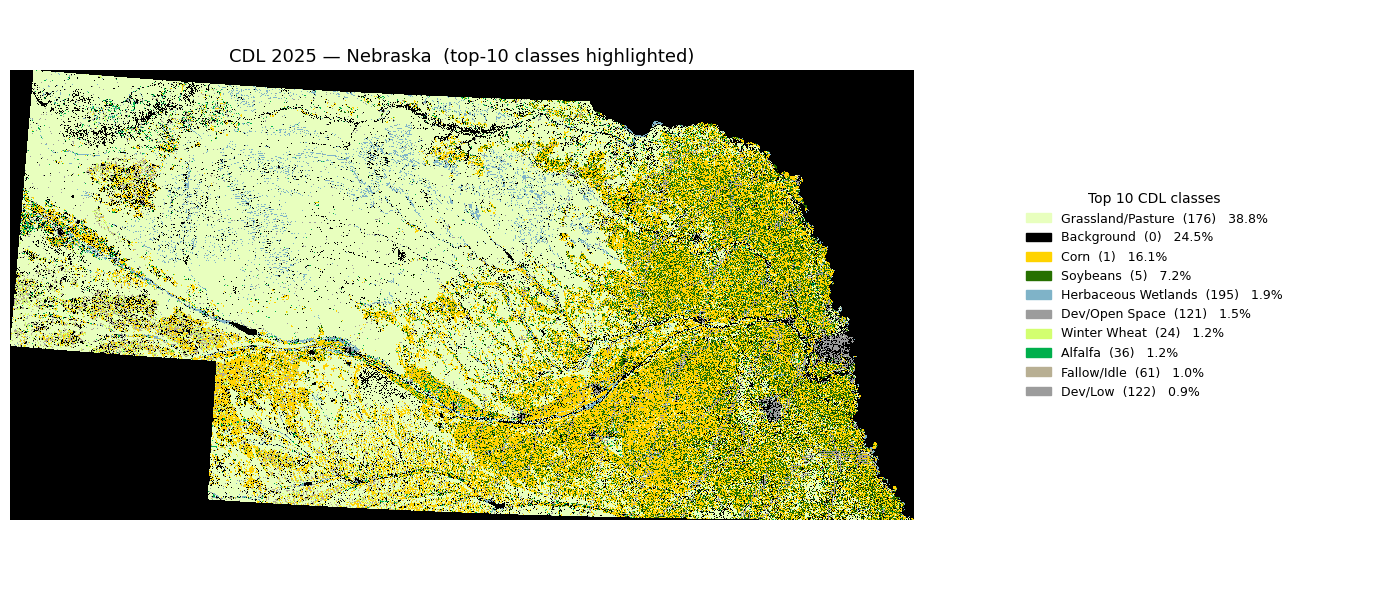

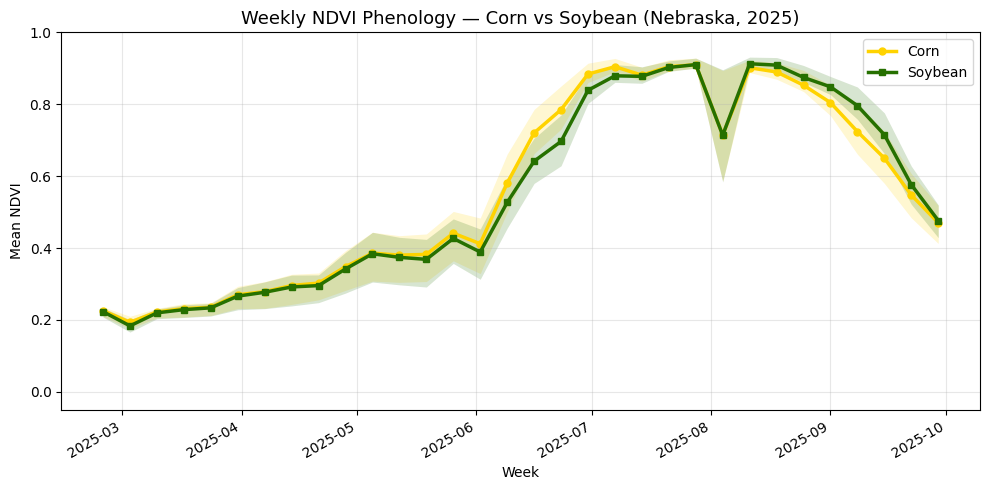

Saved → plots/ndvi_weekly_timeseries_Nebraska_2025_20260412145515.png


In [27]:


# 1. Load states and years from external JSON
with open("task1_config.json", "r") as f:
    config = json.load(f)
    
years = config.get("years", [])
states = config.get("states", [])

CROPSCAPE_BASE = "https://nassgeodata.gmu.edu/axis2/services/CDLService"

# 2. Iterate through each state and year
for state_name in states:
    for year in years:
        print(f"\n{'='*60}\nProcessing {state_name} for {year}...\n{'='*60}")
        
        fips, bbox = get_state_info(state_name)
        
        # Skip if state isn't found
        if not fips:
            continue
            
        download_cdl_tif(year, fips, out_path=f"cdl_{year}_{fips}.tif")
        CDL_FILE = f"cdl_{year}_{fips}.tif"  # adjust path if needed

        with rasterio.open(CDL_FILE) as src:
            cdl = src.read(1)                  # 2-D uint8 array of crop codes
            cdl_profile = src.profile          # stores CRS / transform / size

        print(f"CDL shape  : {cdl.shape}")
        print(f"CDL dtype  : {cdl.dtype}")
        print(f"CRS        : {cdl_profile['crs']}")
        print(f"Resolution : {cdl_profile['transform'].a:.1f} m")

        unique_vals = np.unique(cdl)
        print("Unique CDL codes:", unique_vals)

        # Count major crop classes
        CORN_CODE    = 1
        SOYBEAN_CODE = 5

        corn_mask = (cdl == CORN_CODE)
        soy_mask  = (cdl == SOYBEAN_CODE)

        print(f"Corn pixels   : {corn_mask.sum():,}")
        print(f"Soybean pixels: {soy_mask.sum():,}")
        
        # Uses your newly refactored function
        plot_top_cdl_classes(cdl=cdl, state_name=state_name, year=year)
        print(corn_mask,soy_mask)
        # Uses your newly refactored function
        summary_df = extract_weekly_ndvi_metrics(year, state_name, cdl_profile, corn_mask, soy_mask)
        
        if not summary_df.empty:
            fig2, ax2 = plt.subplots(figsize=(10, 5))

            STYLES = {
                "corn":    {"color": "#FFD300", "marker": "o", "label": "Corn"},
                "soybean": {"color": "#267000", "marker": "s", "label": "Soybean"},
            }

            for crop, sty in STYLES.items():
                df_c = summary_df[summary_df["crop"] == crop].sort_values("date")
                if df_c.empty:
                    continue

                # Mean weekly NDVI line
                ax2.plot(
                    df_c["date"],
                    df_c["mean_ndvi"],
                    color=sty["color"],
                    marker=sty["marker"],
                    markersize=5,
                    linewidth=2.5,
                    label=sty["label"],
                )

                # Weekly IQR band
                ax2.fill_between(
                    df_c["date"],
                    df_c["q25_ndvi"],
                    df_c["q75_ndvi"],
                    color=sty["color"],
                    alpha=0.18,
                    linewidth=0,
                )

            now = datetime.now().strftime("%Y%m%d%H%M%S")

            ax2.set_title(
                f"Weekly NDVI Phenology — Corn vs Soybean ({state_name}, {year})",
                fontsize=13
            )
            ax2.set_xlabel("Week")
            ax2.set_ylabel("Mean NDVI")
            ax2.set_ylim(-0.05, 1.0)
            ax2.grid(True, alpha=0.3)

            # cleaner legend: only crop lines, not IQR fills
            ax2.legend(fontsize=10)

            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()

            # Ensure plots directory exists
            os.makedirs("plots", exist_ok=True)
            out_file = f"plots/ndvi_weekly_timeseries_{state_name}_{year}_{now}.png"
            
            plt.savefig(out_file, dpi=150, bbox_inches="tight")
            plt.show()
            
            # Close figure so memory is released across loop iterations
            plt.close(fig2)

            print(f"Saved → {out_file}")

        else:
            print(f"summary_df is empty for {state_name} ({year}) — run the weekly download/processing cell first.")
for f in glob.glob("*.tif"): os.remove(f)
